In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats


# Plotting params

In [13]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 7,
    "axes.labelsize": 6,
    "axes.labelweight": "bold",
    "font.weight": "bold",
    "axes.titlesize": 7,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 5.5,
    "legend.fontsize": 7,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.figsize": (3.25, 2.6),      # for 0.5\textwidth plot

    "axes.linewidth": 0.8,
    "lines.linewidth": 1.0,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 1.0,
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

folder_name_png = 'PLOTS_BANDITS_PNG'
folder_name_svg = 'PLOTS_BANDITS_SVG'
save_fig = True
alpha = 1


# Normal vs PD data

In [14]:
# reading pickle file
with open(r'DATA/non_stationary_bandits_normal_all.pkl', 'rb') as f:
    data_normal = pickle.load(f)

with open(r'DATA/non_stationary_bandits_pd_all.pkl', 'rb') as f:
    data_pd = pickle.load(f)


In [15]:
bin_change = 75

# normal data
accuracy_percentages_normal = data_normal['accuracy']
avg_accuracy_per_bin_normal = np.mean(accuracy_percentages_normal, axis=0)
epsilon_monitor_normal = data_normal['epsilon_monitor']
arm_chosen_monitor_normal = data_normal['arm_chosen_monitor']
synch_monitor_normal = data_normal['sync_monitor']
entropy_monitor_normal = data_normal['entropy_monitor']

# pd data
accuracy_percentages_pd = data_pd['accuracy']
avg_accuracy_per_bin_pd = np.mean(accuracy_percentages_pd, axis=0)
epsilon_monitor_pd = data_pd['epsilon_monitor']
arm_chosen_monitor_pd = data_pd['arm_chosen_monitor']
synch_monitor_pd = data_pd['sync_monitor']
entropy_monitor_pd = data_pd['entropy_monitor']

bins = np.arange(1, 16)


## DBS data

In [16]:
# Reading pickle file
with open(r'DATA/non_stationary_bandits_DBS.pkl', 'rb') as f:
    data_dbs = pickle.load(f)
cases = list(data_dbs.keys())
del_lim = list(data_dbs['PD'].keys())

last_bin_accuracies_dict = {case: [] for case in cases}
last_bin_sem_dict = {case: [] for case in cases}
for case in cases:
    accuracy_mon = []
    sem_mon = []
    for delta in del_lim:
        last_bin_values = data_dbs[case][delta][:, -1]   # (n_patients,) at the final bin
        accuracy_mon.append(last_bin_values.mean())
        sem_mon.append(last_bin_values.std(ddof=1) / np.sqrt(len(last_bin_values)))
    last_bin_accuracies_dict[case] = accuracy_mon
    last_bin_sem_dict[case] = sem_mon

del_lim_values_PD = list(data_dbs['PD'].keys())
bandit_scores_pd = last_bin_accuracies_dict['PD']
bandit_sem_pd = last_bin_sem_dict['PD']

del_lim_values_std_DBS = list(data_dbs['std DBS'].keys())
bandit_scores_std_DBS = last_bin_accuracies_dict['std DBS']
bandit_sem_std_DBS = last_bin_sem_dict['std DBS']

del_lim_values_open_loop_low_amp = list(data_dbs['Open loop low amp'].keys())
bandit_scores_open_loop_low_amp = last_bin_accuracies_dict['Open loop low amp']
bandit_sem_open_loop_low_amp = last_bin_sem_dict['Open loop low amp']

del_lim_values_open_loop_high_amp = list(data_dbs['Open loop high amp'].keys())
bandit_scores_open_loop_high_amp = last_bin_accuracies_dict['Open loop high amp']
bandit_sem_open_loop_high_amp = last_bin_sem_dict['Open loop high amp']

del_lim_values_closed_loop = list(data_dbs['closed loop'].keys())
bandit_scores_closed_loop = last_bin_accuracies_dict['closed loop']
bandit_sem_closed_loop = last_bin_sem_dict['closed loop']


## Exploratory index (choice-entropy proxy, computed from arm_chosen_monitor)

In [17]:
def exploratory_index(choices, window=None, n_points=None, step=None,
                       method="entropy", n_arms=None, aggregate=True):
    """
    Compute a sliding/binned exploratory index from a matrix of chosen arms.

    Parameters
    ----------
    choices : array-like, shape (n_patients, n_trials)
        Integer arm index chosen by each patient on each trial (0..n_arms-1).
    window : int, optional
        Number of trials per window. Give either this OR n_points, not both.
    n_points : int, optional
        Desired number of output points. Window size is derived as
        n_trials // n_points (non-overlapping). Trailing leftover trials
        that don\'t fill a full window are dropped.
    step : int, optional
        Step size between window starts. Defaults to `window` (non-overlapping
        / tumbling bins). Set step < window for an overlapping sliding window.
    method : {"entropy", "switch_rate", "unique_ratio", "top_arm_share"}
        "entropy"        - normalized Shannon entropy of the arm-choice
                            distribution within the window.
        "switch_rate"    - fraction of trials where choice differs from the
                            previous trial.
        "unique_ratio"   - distinct arms used / n_arms.
        "top_arm_share"  - 1 - (count of most-chosen arm / window size).
    n_arms : int, optional
        Number of possible arms. Inferred as choices.max()+1 if not given.
    aggregate : bool, default True
        If True, return the group-mean curve. If False, return the full
        (n_patients, n_windows) array.

    Returns
    -------
    centers : ndarray, shape (n_windows,)
    values : ndarray, shape (n_windows,) or (n_patients, n_windows)
    """
    choices = np.asarray(choices)
    if choices.ndim != 2:
        raise ValueError("choices must be 2D: (n_patients, n_trials)")
    n_patients, n_trials = choices.shape

    if window is None and n_points is None:
        raise ValueError("specify either window or n_points")
    if window is not None and n_points is not None:
        raise ValueError("specify only one of window / n_points")
    if window is None:
        window = n_trials // n_points
        if window < 1:
            raise ValueError("n_points too large for n_trials")

    if step is None:
        step = window

    if n_arms is None:
        n_arms = int(choices.max()) + 1

    starts = list(range(0, n_trials - window + 1, step))
    if not starts:
        raise ValueError("window larger than n_trials")

    dropped = n_trials - (starts[-1] + window)
    if dropped > 0:
        print(f"note: {dropped} trailing trial(s) dropped "
              f"(n_trials={n_trials} not evenly divisible by window/step)")

    centers = np.array([s + window / 2 for s in starts])
    out = np.empty((n_patients, len(starts)))

    for wi, s in enumerate(starts):
        segment = choices[:, s:s + window]
        for p in range(n_patients):
            seq = segment[p]
            if method == "entropy":
                counts = np.bincount(seq, minlength=n_arms)
                probs = counts / counts.sum()
                probs = probs[probs > 0]
                ent = -np.sum(probs * np.log2(probs))
                max_ent = np.log2(n_arms) if n_arms > 1 else 1
                out[p, wi] = ent / max_ent
            elif method == "switch_rate":
                out[p, wi] = np.mean(seq[1:] != seq[:-1]) if len(seq) > 1 else 0.0
            elif method == "unique_ratio":
                out[p, wi] = len(np.unique(seq)) / n_arms
            elif method == "top_arm_share":
                counts = np.bincount(seq, minlength=n_arms)
                out[p, wi] = 1 - counts.max() / counts.sum()
            else:
                raise ValueError(f"unknown method: {method}")

    if aggregate:
        return centers, out.mean(axis=0)
    return centers, out


## Shared population-level computations (used by all three figures below)

In [18]:
# ============================================================
# Shared population-level computations, used by all three figures below.
# Nothing here changes example_idx_normal / example_idx_pd -- kept as-is.
# ============================================================

# --- epsilon: mean +/- SEM across patients ---
eps_normal_all = np.asarray(data_normal['epsilon_monitor'])
eps_pd_all = np.asarray(data_pd['epsilon_monitor'])
assert eps_normal_all.shape[1] == eps_pd_all.shape[1], "trial count mismatch between groups"

mean_eps_normal = eps_normal_all.mean(axis=0)
mean_eps_pd = eps_pd_all.mean(axis=0)
sem_eps_normal = eps_normal_all.std(axis=0, ddof=1) / np.sqrt(eps_normal_all.shape[0])
sem_eps_pd = eps_pd_all.std(axis=0, ddof=1) / np.sqrt(eps_pd_all.shape[0])
trials_eps = np.arange(eps_normal_all.shape[1])

# --- k, propagated directly from epsilon (deterministic affine transform) ---
mean_k_normal = 0.5 * mean_eps_normal + 0.4
mean_k_pd = 0.5 * mean_eps_pd + 0.4
sem_k_normal = 0.5 * sem_eps_normal
sem_k_pd = 0.5 * sem_eps_pd

# --- exploratory index (population mean +/- SEM, entropy of arm choices) ---
choices_normal_all = np.asarray(data_normal['arm_chosen_monitor'])
choices_pd_all = np.asarray(data_pd['arm_chosen_monitor'])
n_arms = 3
window = 6

centers, expl_normal_per_patient = exploratory_index(
    choices_normal_all, window=window, method="entropy", n_arms=n_arms, aggregate=False)
_, expl_pd_per_patient = exploratory_index(
    choices_pd_all, window=window, method="entropy", n_arms=n_arms, aggregate=False)

mean_expl_normal = expl_normal_per_patient.mean(axis=0)
mean_expl_pd = expl_pd_per_patient.mean(axis=0)
sem_expl_normal = expl_normal_per_patient.std(axis=0, ddof=1) / np.sqrt(expl_normal_per_patient.shape[0])
sem_expl_pd = expl_pd_per_patient.std(axis=0, ddof=1) / np.sqrt(expl_pd_per_patient.shape[0])

# --- NEW: sync, mean +/- SEM across patients ---
sync_normal_all = np.asarray(synch_monitor_normal)
sync_pd_all = np.asarray(synch_monitor_pd)
assert sync_normal_all.shape[1] == eps_normal_all.shape[1], "sync trial count doesn't match epsilon's"

mean_sync_normal = sync_normal_all.mean(axis=0)
mean_sync_pd = sync_pd_all.mean(axis=0)
sem_sync_normal = sync_normal_all.std(axis=0, ddof=1) / np.sqrt(sync_normal_all.shape[0])
sem_sync_pd = sync_pd_all.std(axis=0, ddof=1) #/ np.sqrt(sync_pd_all.shape[0])

# --- NEW: entropy_monitor, mean +/- SEM across patients ---
# NOTE: this is a different quantity from `exploratory_index` above (that one is
# computed here from arm_chosen_monitor; this one comes straight from your pickle).
# If entropy_monitor also measures choice-entropy, showing both is redundant --
# worth confirming what it actually represents before presenting both as distinct.
entropy_normal_all = np.asarray(entropy_monitor_normal)
entropy_pd_all = np.asarray(entropy_monitor_pd)
assert entropy_normal_all.shape[1] == eps_normal_all.shape[1], "entropy trial count doesn't match epsilon's"

mean_entropy_normal = entropy_normal_all.mean(axis=0)
mean_entropy_pd = entropy_pd_all.mean(axis=0)
sem_entropy_normal = entropy_normal_all.std(axis=0, ddof=1) / np.sqrt(entropy_normal_all.shape[0])
sem_entropy_pd = entropy_pd_all.std(axis=0, ddof=1) #/ np.sqrt(entropy_pd_all.shape[0])

# --- accuracy SEM across patients, per bin ---
sem_accuracy_normal = accuracy_percentages_normal.std(axis=0, ddof=1) / np.sqrt(accuracy_percentages_normal.shape[0])
sem_accuracy_pd = accuracy_percentages_pd.std(axis=0, ddof=1) / np.sqrt(accuracy_percentages_pd.shape[0])

# --- single-instance example for the raw choice raster (illustrative only) ---
# kept exactly as currently used -- not changed
example_idx_normal = 0
example_idx_pd = 1
arm_chosen_example_normal = data_normal['arm_chosen_monitor'][example_idx_normal]
arm_chosen_example_pd = data_pd['arm_chosen_monitor'][example_idx_pd]

normal_colors = ['#a6cee3', '#1f78b4', '#08306b']
pd_colors = ['#fbb4ae', '#e31a1c', "#4F0711"]


In [19]:
print(f'last bin accuracy under Normal: {avg_accuracy_per_bin_normal[-1]}')
print(f'last bin accuracy under Normal: {bandit_scores_pd[-1]}')
print(f'last bin accuracy under Closed loop DBS (del lim = 1.0): {bandit_scores_closed_loop[-1]}')
print(f'last bin accuracy under Open loop high (del lim = 1.0): {bandit_scores_open_loop_high_amp[-1]}')
print(f'last bin accuracy under Open loop low (del lim = 1.0): {bandit_scores_open_loop_low_amp[-1]}')
print(f'last bin accuracy under std DBS (del lim = 1.0): {bandit_scores_std_DBS[-1]}')

last bin accuracy under Normal: 82.5
last bin accuracy under Normal: 2.0
last bin accuracy under Closed loop DBS (del lim = 1.0): 65.0
last bin accuracy under Open loop high (del lim = 1.0): 59.400001525878906
last bin accuracy under Open loop low (del lim = 1.0): 7.0
last bin accuracy under std DBS (del lim = 1.0): 2.0


## Panel-drawing helpers (used by all three figures below)

In [20]:
# ============================================================
# Panel-drawing helpers, one per row-type. Used by all three figure cells
# below so the styling only has to be defined once.
# ============================================================

def draw_epsilon(ax_n, ax_p):
    ax_n.plot(trials_eps, mean_eps_normal, color='tab:blue', label='Normal')
    ax_n.fill_between(trials_eps, mean_eps_normal - sem_eps_normal, mean_eps_normal + sem_eps_normal,
                       color='tab:blue', alpha=0.3, linewidth=0)
    ax_n.axhline(y=0.1, color='gray', linestyle='--', linewidth=0.8)
    ax_n.axvline(x=75, color='black', linestyle=':', linewidth=0.4)
    ax_n.set_ylim(0.05, 0.35)
    ax_n.set_ylabel(r'$\epsilon$', fontsize=6)
    ax_n.set_xlabel('Trials', fontsize=6)
    ax_n.legend(frameon=False, loc='upper right', fontsize=6)

    ax_p.plot(trials_eps, mean_eps_pd, color='tab:red', label='PD')
    ax_p.fill_between(trials_eps, mean_eps_pd - sem_eps_pd, mean_eps_pd + sem_eps_pd,
                       color='tab:red', alpha=0.3, linewidth=0)
    ax_p.axhline(y=0.1, color='gray', linestyle='--', linewidth=0.8)
    ax_p.axvline(x=75, color='black', linestyle=':', linewidth=0.4)
    ax_p.set_ylim(0.0575, 0.125)
    ax_p.set_xlabel('Trials', fontsize=6)
    ax_p.set_ylabel(r'$\epsilon$', fontsize=6)
    ax_p.legend(frameon=False, loc='upper right', fontsize=6)


def draw_k(ax_n, ax_p):
    ax_n.plot(trials_eps, mean_k_normal, color='tab:blue', label='Normal')
    ax_n.fill_between(trials_eps, mean_k_normal - sem_k_normal, mean_k_normal + sem_k_normal,
                       color='tab:blue', alpha=0.2, linewidth=0)
    ax_n.axhline(y=0.45, color='gray', linestyle='--', linewidth=0.8)
    ax_n.axvline(x=75, color='black', linestyle=':', linewidth=0.4)
    ax_n.set_ylim(0.40, 0.56)
    ax_n.set_ylabel('$k$', fontsize=6)
    ax_n.set_xlabel('Trials', fontsize=6)
    ax_n.legend(frameon=False, loc='upper right', fontsize=6)

    ax_p.plot(trials_eps, mean_k_pd, color='tab:red', label = 'PD')
    ax_p.fill_between(trials_eps, mean_k_pd - sem_k_pd, mean_k_pd + sem_k_pd,
                       color='tab:red', alpha=0.2, linewidth=0)
    ax_p.axhline(y=0.45, color='gray', linestyle='--', linewidth=0.8)
    ax_p.axvline(x=75, color='black', linestyle=':', linewidth=0.4)
    ax_p.set_ylim(0.425, 0.475)
    ax_p.set_ylabel('$k$', fontsize=6)
    ax_p.set_xlabel('Trials', fontsize=6)
    ax_p.legend(frameon=False, loc='upper right', fontsize=6)


def draw_exploratory_index(ax_n, ax_p):
    ax_n.plot(centers, mean_expl_normal, color='tab:blue', label = 'Normal')
    ax_n.fill_between(centers, mean_expl_normal - sem_expl_normal, mean_expl_normal + sem_expl_normal,
                       color='tab:blue', alpha=0.2, linewidth=0)
    ax_n.axvline(x=75, color='black', linestyle=':', linewidth=0.4)
    ax_n.set_ylim(0, 1)
    ax_n.set_ylabel('Exploration index', fontsize=6)
    ax_n.set_xlabel('Trials', fontsize=6)
    ax_n.legend(frameon=False, loc='upper right', fontsize=6)
    ax_p.plot(centers, mean_expl_pd, color='tab:red', label = 'PD')
    ax_p.fill_between(centers, mean_expl_pd - sem_expl_pd, mean_expl_pd + sem_expl_pd,
                       color='tab:red', alpha=0.2, linewidth=0)
    ax_p.axvline(x=75, color='black', linestyle=':', linewidth=0.4)
    ax_p.set_ylim(0, 1)
    ax_p.set_ylabel('Exploration index', fontsize=6)
    ax_p.set_xlabel('Trials', fontsize=6)
    ax_p.legend(frameon=False, loc='upper right', fontsize=6)

def draw_sync(ax_n, ax_p):
    # NOTE: no reference hline / fixed ylim here -- unlike eps/k, there's no
    # established target value for sync yet. Left auto-scaled; add bounds once
    # you know what range is meaningful.
    ax_n.plot(trials_eps, mean_sync_normal, color='tab:blue', label = 'Normal')
    ax_n.fill_between(trials_eps, mean_sync_normal - sem_sync_normal, mean_sync_normal + sem_sync_normal,
                       color='tab:blue', alpha=0.2, linewidth=0)
    ax_n.axvline(x=75, color='black', linestyle=':', linewidth=0.4)
    # ax_n.axhline(y=0.75, color='black', linestyle='--', linewidth=0.4)
    ax_n.set_ylabel('$R_{sync}$', fontsize=6)
    ax_n.set_xlabel('Trials', fontsize=6)
    ax_n.legend(frameon=False, loc='upper right', fontsize=6, bbox_to_anchor=(1, 1.2))
    ax_p.plot(trials_eps, mean_sync_pd, color='tab:red', label = 'PD')
    ax_p.fill_between(trials_eps, mean_sync_pd - sem_sync_pd, mean_sync_pd + sem_sync_pd,
                       color='tab:red', alpha=0.2, linewidth=0)
    ax_p.axvline(x=75, color='black', linestyle=':', linewidth=0.4)
    # ax_p.axhline(y=0.75, color='black', linestyle='--', linewidth=0.4)
    ax_p.set_ylabel('$R_{sync}$', fontsize=6)
    ax_p.set_xlabel('Trials', fontsize=6)
    ax_p.legend(frameon=False, loc='upper right', fontsize=6, bbox_to_anchor=(1, 1.2))
    ax_n.set_ylim(0.1, 1)
    ax_p.set_ylim(0.6, 1)


def draw_entropy(ax_n, ax_p):
    # same caveat as draw_sync: ylim left auto, no reference line yet
    ax_n.plot(trials_eps, mean_entropy_normal, color='tab:blue', label = 'Normal')
    ax_n.fill_between(trials_eps, mean_entropy_normal - sem_entropy_normal, mean_entropy_normal + sem_entropy_normal,
                       color='tab:blue', alpha=0.2, linewidth=0)
    ax_n.axvline(x=75, color='black', linestyle=':', linewidth=0.4)
    # ax_n.axhline(y=0.5, color='black', linestyle='--', linewidth=0.4)
    ax_n.set_ylabel('$H_{s}$', fontsize=6)
    ax_n.set_xlabel('Trials', fontsize=6)

    ax_p.plot(trials_eps, mean_entropy_pd, color='tab:red', label = 'PD')
    ax_p.fill_between(trials_eps, mean_entropy_pd - sem_entropy_pd, mean_entropy_pd + sem_entropy_pd,
                       color='tab:red', alpha=0.2, linewidth=0)
    ax_p.axvline(x=75, color='black', linestyle=':', linewidth=0.4)
    # ax_p.axhline(y=0.5, color='black', linestyle='--', linewidth=0.4)
    ax_p.set_ylabel('$H_{s}$', fontsize=6)
    ax_p.set_xlabel('Trials', fontsize=6)
    
    ax_n.set_ylim(0.0, 0.75)
    ax_p.set_ylim(0.0, 0.75)
    ax_p.legend(frameon=False, loc='upper right', fontsize=6)
    ax_n.legend(frameon=False, loc='upper right', fontsize=6)

def draw_raster(ax_n, ax_p):
    for arm, color in zip(range(3), normal_colors):
        trials_arm = np.where(arm_chosen_example_normal == arm)[0]
        ax_n.eventplot(trials_arm, lineoffsets=arm, colors=color, linelengths=0.3, linewidths=0.75)
    ax_n.set_yticks([0, 1, 2])
    ax_n.set_yticklabels(['Arm 1', 'Arm 2', 'Arm 3'], fontsize=6)
    ax_n.set_xlabel('Trials', fontsize=6)
    ax_n.set_xlim(0, len(arm_chosen_example_normal) - 1)
    ax_n.set_ylim(-0.5, 2.5)

    for arm, color in zip(range(3), pd_colors):
        trials_arm = np.where(arm_chosen_example_pd == arm)[0]
        ax_p.eventplot(trials_arm, lineoffsets=arm, colors=color, linelengths=0.3, linewidths=0.75)
    ax_p.set_yticks([0, 1, 2])
    ax_p.set_yticklabels(['Arm 1', 'Arm 2', 'Arm 3'], fontsize=6)
    ax_p.set_xlabel('Trials', fontsize=6)
    ax_p.set_xlim(0, len(arm_chosen_example_pd) - 1)
    ax_p.set_ylim(-0.5, 2.5)

    normal_handle = Line2D([0], [0], color='tab:blue', lw=1, label='Normal')
    pd_handle = Line2D([0], [0], color='tab:red', lw=1, label='PD')

    ax_n.legend(handles=[normal_handle], frameon=False, loc='upper right', fontsize=6, bbox_to_anchor=(1, 1.2))
    ax_p.legend(handles=[pd_handle], frameon=False, loc='upper right', fontsize=6, bbox_to_anchor=(1, 1.2))

def draw_accuracy(ax1):
    ax1.errorbar(bins, avg_accuracy_per_bin_normal, yerr=sem_accuracy_normal,
                 fmt='o-', color='tab:blue', label='Normal', markersize=1,
                 linewidth=1, elinewidth=0.4, capsize=1)
    # ax1.fill_between(bins, avg_accuracy_per_bin_normal - sem_accuracy_normal,
    #                   avg_accuracy_per_bin_normal + sem_accuracy_normal,
    #                   color='tab:blue', alpha=0.15, linewidth=0)

    ax1.errorbar(bins, avg_accuracy_per_bin_pd, yerr=sem_accuracy_pd,
                 fmt='s-', color='tab:red', label='PD', markersize=1,
                 linewidth=1, elinewidth=0.4, capsize=1)
    # ax1.fill_between(bins, avg_accuracy_per_bin_pd - sem_accuracy_pd,
    #                   avg_accuracy_per_bin_pd + sem_accuracy_pd,
    #                   color='tab:red', alpha=0.15, linewidth=0)

    ax1.axvline(x=8, color='black', linestyle=':', linewidth=0.4)
    ax1.set_ylim(0, 100)
    ax1.axvspan(0.5, 8, color="#e0f2f1", alpha=0.1)
    ax1.axvspan(8, 15.5, color="#e0f2f1", alpha=1)
    arrow_y = 80
    ax1.annotate('Reward Change', xy=(8, arrow_y), xytext=(9, arrow_y + 10),
                 arrowprops=dict(facecolor='gray', shrink=0.05, width=1.25, headwidth=3, headlength=5,
                                  linestyle='-', alpha=0.7),
                 fontsize=6, color='black', fontweight='bold', va='bottom')
    ax1.legend(frameon=False, loc='lower left', fontsize=6)
    ax1.set_xlabel('Bins', fontsize=6)
    ax1.set_ylabel('% optimal choice', fontsize=6)
    ax1.set_xticks(bins)
    ax1.set_xlim(0.5, 15.5)


def draw_dbs(ax6):
    bar_width = 0.1
    x_values = np.arange(len(del_lim_values_PD))
    err_style = dict(elinewidth=0.6, capsize=1.5, capthick=0.6)

    ax6.bar(x_values - bar_width * 2, bandit_scores_pd, width=bar_width, yerr=bandit_sem_pd,
            label="PD", alpha=alpha, color='#d62728', error_kw=err_style)
    ax6.bar(x_values - bar_width, bandit_scores_std_DBS, width=bar_width, yerr=bandit_sem_std_DBS,
            label="Standard DBS", alpha=alpha, color='#691fb4', error_kw=err_style)
    ax6.bar(x_values, bandit_scores_open_loop_low_amp, width=bar_width, yerr=bandit_sem_open_loop_low_amp,
            label="Open-loop: low", alpha=alpha, color='#e377c2', error_kw=err_style)
    ax6.bar(x_values + bar_width, bandit_scores_open_loop_high_amp, width=bar_width, yerr=bandit_sem_open_loop_high_amp,
            label="Open-loop: high", alpha=alpha, color='#ff7f0e', error_kw=err_style)
    ax6.bar(x_values + bar_width * 2, bandit_scores_closed_loop, width=bar_width, yerr=bandit_sem_closed_loop,
            label="Closed-loop", alpha=alpha, color="#2ca02c", error_kw=err_style)

    ax6.set_xlabel(r"$\delta_{lim}$", fontsize=6)
    ax6.set_ylabel(r"$\%$ optimal choice at last bin", fontsize=6)
    ax6.set_ylim(-1, 100)
    ax6.legend(loc="upper left", frameon=False, bbox_to_anchor=(0, -0.275), fontsize=6, ncol=3)
    ax6.set_xticks(x_values, [f"{v:.2f}" for v in del_lim_values_PD], rotation=0)
    ax6.tick_params(axis='both', which='major', length=3)


def label_panels(axes, labels, y=1.25):
    for ax, label in zip(axes, labels):
        ax.text(-0.15, y, label, transform=ax.transAxes, fontsize=7.5, fontweight='bold', va='top', ha='left')


---
## Figure 1: everything, including sync & entropy

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


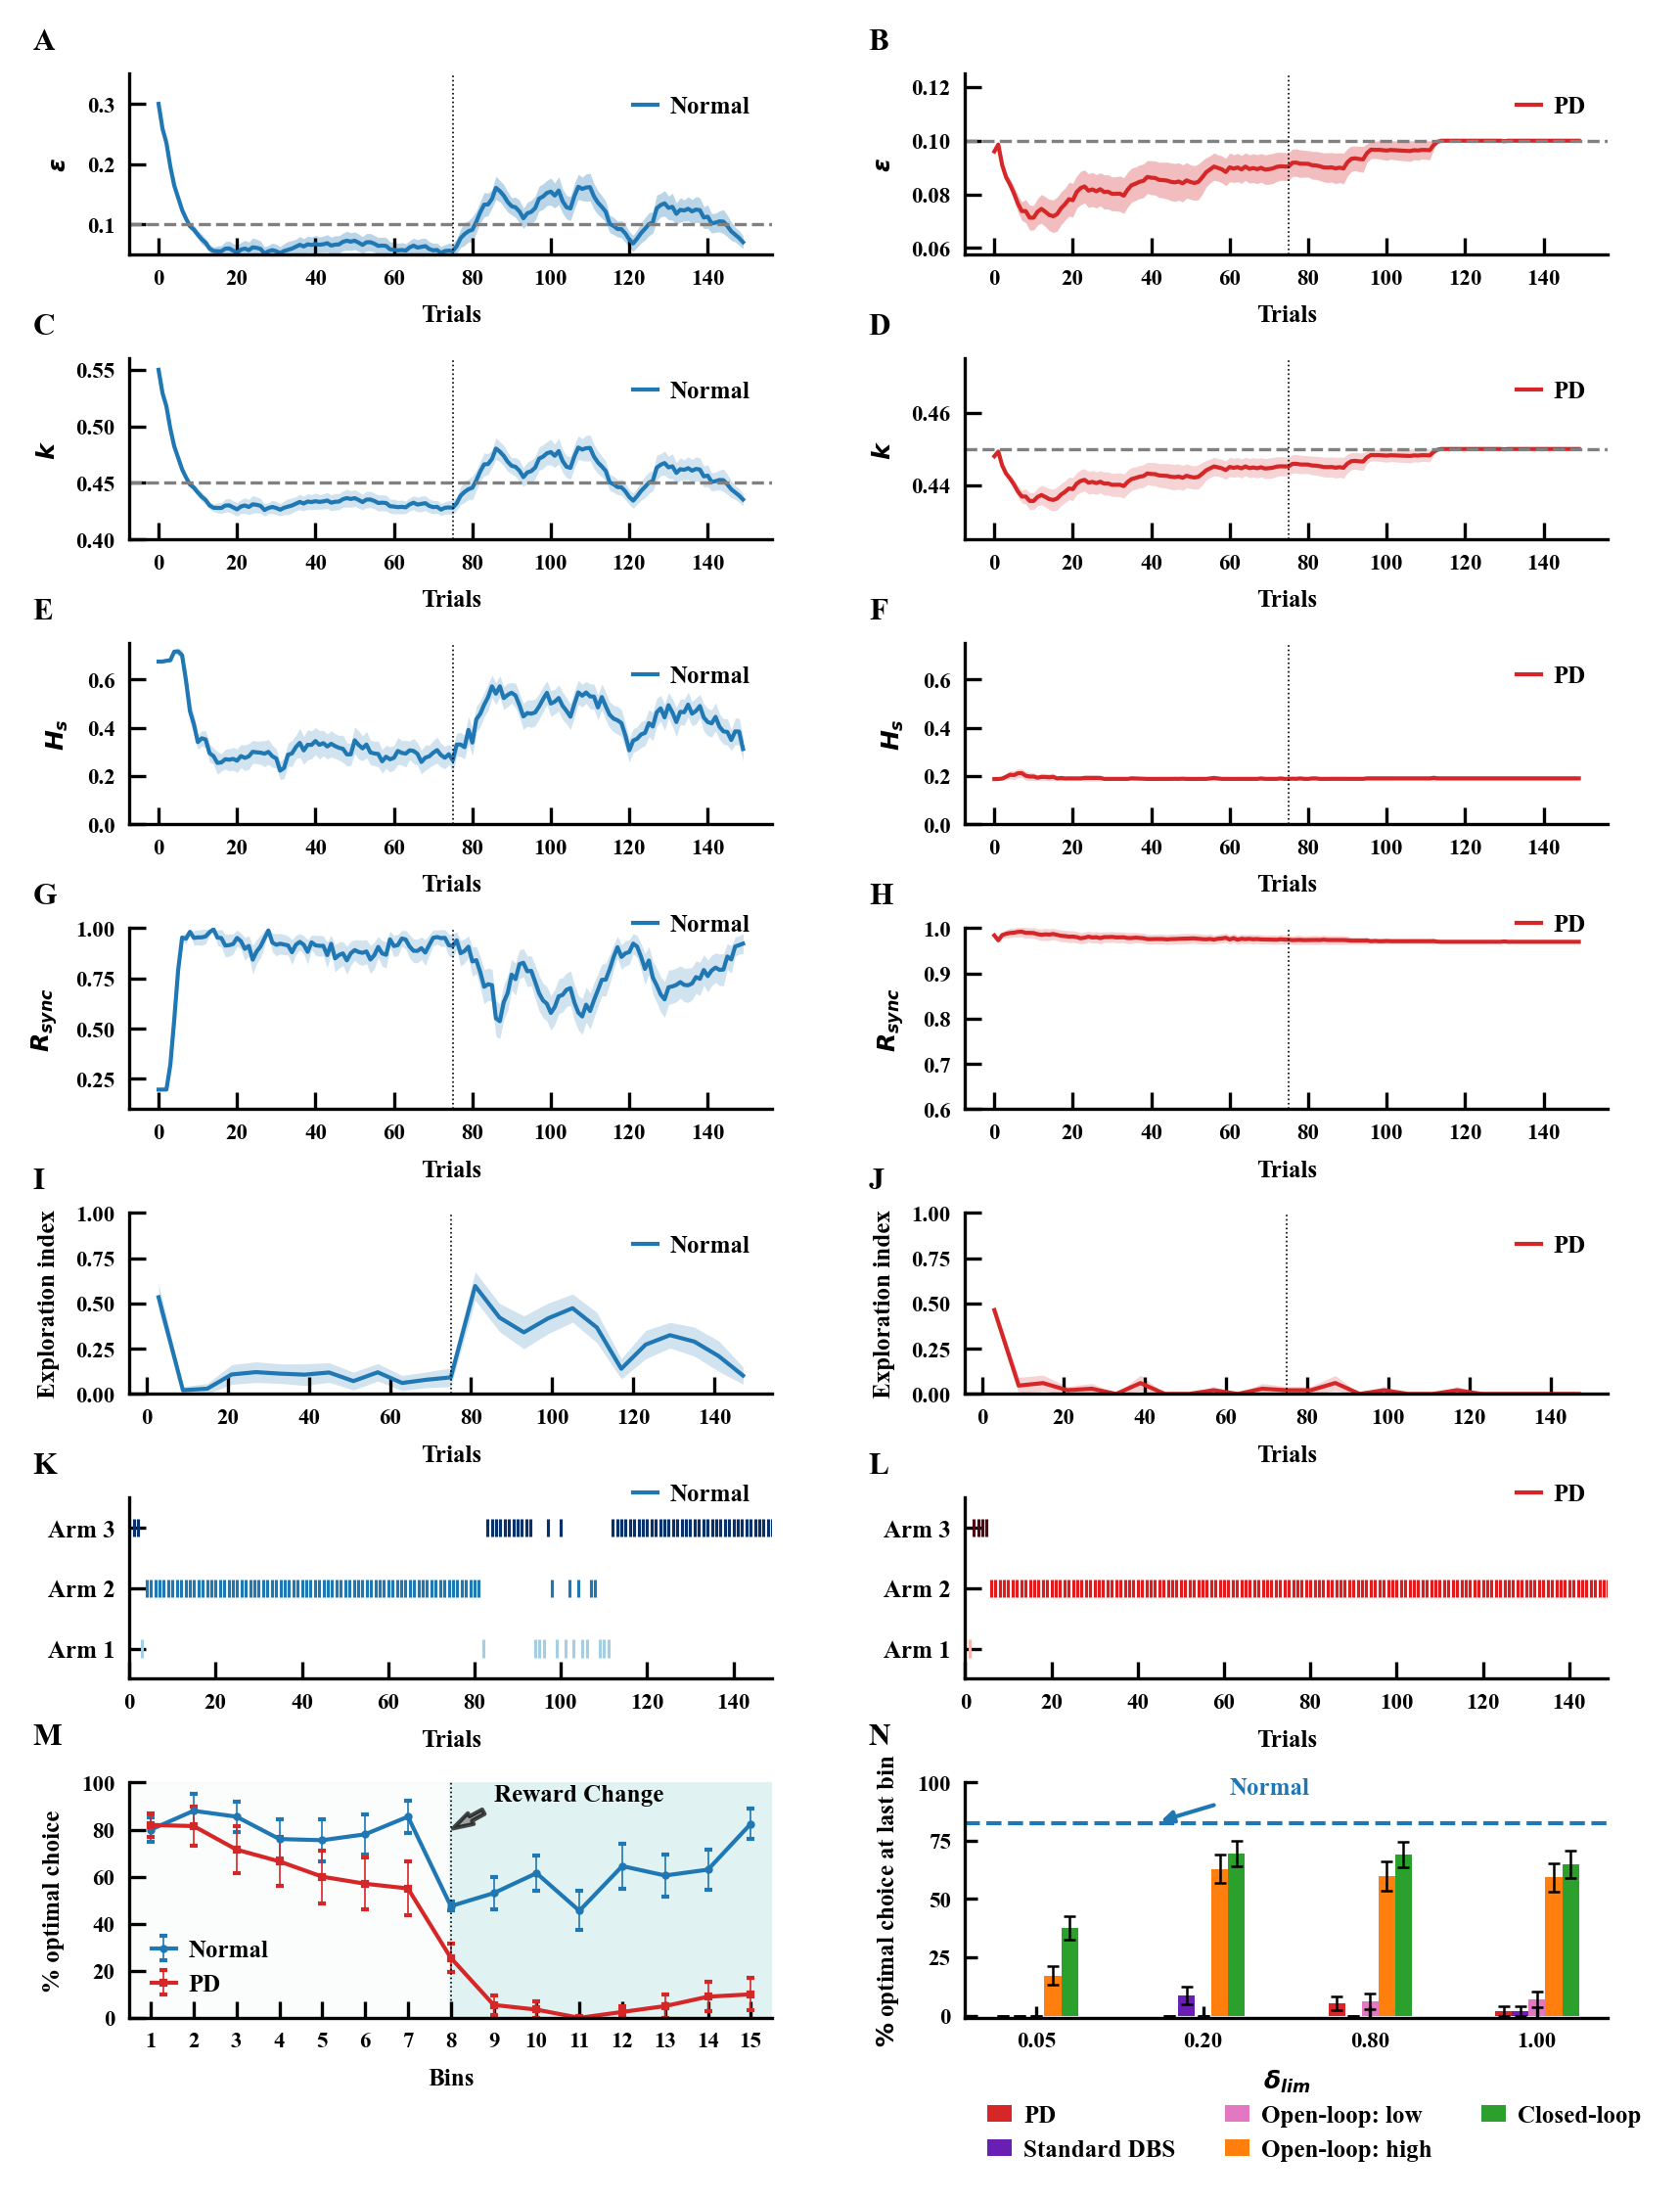

In [21]:
# ================= FIGURE: everything, including sync & entropy =================
fig = plt.figure(figsize=(6.5, 8.6), constrained_layout=False)
gs = fig.add_gridspec(7, 2, height_ratios=[1, 1, 1, 1, 1, 1, 1.3])

ax_eps_n = fig.add_subplot(gs[0, 0]); ax_eps_p = fig.add_subplot(gs[0, 1])
draw_epsilon(ax_eps_n, ax_eps_p)

ax_k_n = fig.add_subplot(gs[1, 0]); ax_k_p = fig.add_subplot(gs[1, 1])
draw_k(ax_k_n, ax_k_p)

ax_ent_n = fig.add_subplot(gs[2, 0]); ax_ent_p = fig.add_subplot(gs[2, 1])
draw_entropy(ax_ent_n, ax_ent_p)

ax_sync_n = fig.add_subplot(gs[3, 0]); ax_sync_p = fig.add_subplot(gs[3, 1])
draw_sync(ax_sync_n, ax_sync_p)


ax_ei_n = fig.add_subplot(gs[4, 0]); ax_ei_p = fig.add_subplot(gs[4, 1])
draw_exploratory_index(ax_ei_n, ax_ei_p)

ax_raster_n = fig.add_subplot(gs[5, 0]); ax_raster_p = fig.add_subplot(gs[5, 1])
draw_raster(ax_raster_n, ax_raster_p)

ax_acc = fig.add_subplot(gs[6, 0]); ax_dbs = fig.add_subplot(gs[6, 1])
draw_accuracy(ax_acc)
draw_dbs(ax_dbs)
# Horizontal reference line at y = 82
ax_dbs.axhline(y=avg_accuracy_per_bin_normal[-1], color='tab:blue', linestyle='--', linewidth=1.0)

# Arrow annotation pointing to the line
ax_dbs.annotate(
    'Normal',
    xy=(0.7, avg_accuracy_per_bin_normal[-1]),        # point on the line (adjust x as needed)
    xytext=(1.4, 95),   # location of the text
    arrowprops=dict(arrowstyle='-|>', lw=1.0, color = 'tab:blue'),
    fontsize=6,
    color='tab:blue',

    ha='center'
)

all_axes = [ax_eps_n, ax_eps_p, ax_k_n, ax_k_p, ax_ent_n, ax_ent_p,
            ax_sync_n, ax_sync_p, ax_ei_n, ax_ei_p,
            ax_raster_n, ax_raster_p, ax_acc, ax_dbs]
all_labels = list("ABCDEFGHIJKLMN")
label_panels(all_axes, all_labels)

fig.subplots_adjust(hspace=0.55, wspace=0.3)

folder_name = 'PLOTS_BANDITS'
if save_fig:
    plt.savefig(
        f'{folder_name}/Bandits_all.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/Bandits_all.svg',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/Bandits_all.eps',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/Bandits_all.pdf',
        dpi=300,
        bbox_inches='tight'
    )


plt.show()
